# Dust and other effects

sncosmo adds dust to a model with **propagation effects**: Milky Way dust in the observer frame, host-galaxy dust
in the rest frame, with any of its extinction laws. {func}`saltjax.fit_salt` takes the same effects, with the same
arguments as `sncosmo.Model`:

```python
saltjax.fit_salt(data, targets,
                 effects=[sncosmo.CCM89Dust(), sncosmo.CCM89Dust()],
                 effect_names=["mw", "host"], effect_frames=["obs", "rest"])
```

The parameters of the effects are **fixed per target**, read from the `targets` columns named `{name}{param}`, as sncosmo
names the model parameters (`mwebv`, `mwr_v`, `hostebv`, `hostr_v`, ...). A missing column means the effect's own value for
all targets. The fit stays $(t_0, x_0, x_1, c)$.

This page simulates SNe Ia with Milky Way and host dust, shows what happens when host dust is ignored, fits it with the
right effects, checks the result against `sncosmo.fit_lc`, and shows the other dust laws and a user-defined effect.

:::{note}
`saltjax` folds the transmission of the effects into the band integrals of each target, exactly, on sncosmo's own wavelength
grid (see [How it works](../how_it_works.rst)). Any effect that is a fixed transmission in wavelength works: the sncosmo dust
laws `CCM89Dust`, `OD94Dust`, `F99Dust`, and your own `sncosmo.PropagationEffect`.
:::

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sncosmo
import saltjax

warnings.filterwarnings("ignore", category=RuntimeWarning)
PARAMS = ["t0", "x0", "x1", "c"]
rng = np.random.default_rng(12)

## Simulate SNe Ia with Milky Way and host dust

We draw 300 SNe Ia between $z=0.02$ and $0.1$, with Milky Way dust (CCM89, observer frame, $R_V=3.1$) and host dust
(CCM89, rest frame) with an exponential $E(B-V)$ distribution and an $R_V$ that varies from host to host. Each SN is observed
in ZTF $g$, $r$, $i$ every 2 to 3 days, with noise. The true model is an `sncosmo.Model` with both effects.

In [2]:
NSN = 300
targets = pd.DataFrame({"z": rng.uniform(0.02, 0.1, NSN),
                        "t0": rng.uniform(59_000, 59_200, NSN),
                        "x1": rng.normal(0, 1, NSN),
                        "c": rng.normal(-0.03, 0.07, NSN),
                        "mwebv": rng.uniform(0, 0.15, NSN),
                        "hostebv": rng.exponential(0.1, NSN),
                        "hostr_v": np.clip(rng.normal(2.5, 0.6, NSN), 1.5, 4.5)},
                       index=pd.Index(np.arange(NSN), name="target"))
targets["x0"] = 1e-2 * (0.03 / targets["z"]) ** 2

truth_model = sncosmo.Model("salt2", effects=[sncosmo.CCM89Dust(), sncosmo.CCM89Dust()],
                            effect_names=["mw", "host"], effect_frames=["obs", "rest"])
lcs = []
for name, row in targets.iterrows():
    time_ = np.sort(row["t0"] + np.arange(-20, 60, 2.5) + rng.normal(0, 0.3, 32))
    band = rng.choice(["ztfg", "ztfr", "ztfi"], len(time_))
    truth_model.set(**{p: row[p] for p in truth_model.param_names if p in row.index})
    flux = truth_model.bandflux(band, time_, zp=25., zpsys="ab")
    fluxerr = 0.02 * flux.max() + 0.03 * np.abs(flux)
    lcs.append(pd.DataFrame({"time": time_, "band": band, "zp": 25., "zpsys": "ab",
                             "flux": flux + rng.normal(0, fluxerr), "fluxerr": fluxerr}))
data = pd.concat(lcs, keys=targets.index, names=["target", "obs"])
print(f"{len(targets)} SNe, {len(data):,} points")
targets[["z", "c", "mwebv", "hostebv", "hostr_v"]].describe().loc[["mean", "std", "min", "max"]].round(3)

300 SNe, 9,600 points


,z,c,mwebv,hostebv,hostr_v
mean,0.061,-0.028,0.072,0.101,2.523
std,0.025,0.074,0.042,0.095,0.591
min,0.020,-0.226,0.002,0.001,1.500
max,0.100,0.229,0.150,0.558,3.953


## Ignoring host dust biases the color

By default, `fit_salt` only applies the Milky Way dust of the `mwebv` column. Host dust then reddens the SN, and the fitted
SALT color $c$ absorbs it: $c$ is biased by about $E(B-V)_\mathrm{host}$.

In [3]:
res_mw = saltjax.fit_salt(data, targets, modelcov=False)
res_mw[["c", "c_err", "mwebv", "mwr_v"]].head()

,c,c_err,mwebv,mwr_v
target,,,,
0,0.039656,0.050107,0.058769,3.1
1,0.228733,0.026391,0.081893,3.1
2,0.055827,0.025885,0.005899,3.1
3,0.105736,0.026748,0.106101,3.1
4,-0.048711,0.025601,0.027537,3.1


## Fit with host dust as an effect

With the host dust as a second effect, named `host` in the rest frame, its parameters are read from the `hostebv` and
`hostr_v` columns of `targets`. The fitted color is now the intrinsic one.

In [4]:
effects = dict(effects=[sncosmo.CCM89Dust(), sncosmo.CCM89Dust()],
               effect_names=["mw", "host"], effect_frames=["obs", "rest"])
t_start = time.perf_counter()
res_host = saltjax.fit_salt(data, targets, modelcov=False, **effects)
print(f"{len(res_host)} SNe fitted in {time.perf_counter() - t_start:.1f} s")
res_host[["c", "c_err", "mwebv", "mwr_v", "hostebv", "hostr_v"]].head()

300 SNe fitted in 0.4 s


,c,c_err,mwebv,mwr_v,hostebv,hostr_v
target,,,,,,
0,-0.071850,0.049773,0.058769,3.1,0.099926,3.011723
1,0.022978,0.026351,0.081893,3.1,0.211674,2.283675
2,-0.075529,0.025787,0.005899,3.1,0.132966,2.469701
3,-0.025801,0.026498,0.106101,3.1,0.125247,3.458941
4,-0.086781,0.025587,0.027537,3.1,0.038253,2.456214


The fixed parameters of every effect are returned as columns, with their sncosmo names.

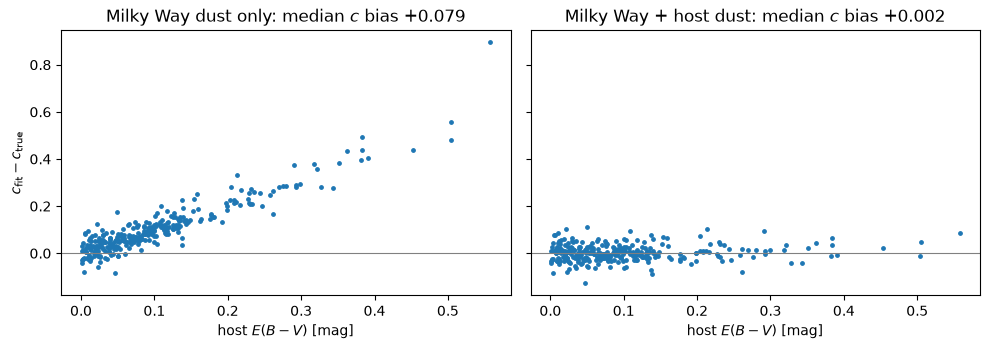

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, (label, res) in zip(axes, [("Milky Way dust only", res_mw), ("Milky Way + host dust", res_host)]):
    dc = res["c"] - targets.loc[res.index, "c"]
    ax.scatter(targets.loc[res.index, "hostebv"], dc, s=6, color="C0")
    ax.axhline(0, color="0.5", lw=0.8)
    ax.set_xlabel(r"host $E(B-V)$ [mag]")
    ax.set_title(f"{label}: median $c$ bias {np.median(dc):+.3f}")
axes[0].set_ylabel(r"$c_\mathrm{fit} - c_\mathrm{true}$")
fig.tight_layout()

In [6]:
pulls = pd.DataFrame({(label, p): ((res[p] - targets.loc[res.index, p]) / res[f"{p}_err"]).agg(["mean", "std"])
                      for label, res in [("MW only", res_mw), ("MW + host", res_host)] for p in ["x1", "c"]}).T
pulls.index.names = ["fit", "parameter"]
pulls.round(2)

mean   std
fit       parameter            
MW only   x1        -0.10  1.06
          c          3.54  3.54
MW + host x1        -0.07  1.05
          c          0.06  1.06

With the host dust, the $x_1$ and $c$ pulls are centered with a unit width; without it, the color pulls are
far off.

## Same results as `sncosmo.fit_lc`

We fit the first 30 SNe with `sncosmo.fit_lc` and the same model (both effects, host parameters fixed), started from the
truth with wide bounds, and compare with `saltjax`, with and without model covariance.

In [7]:
def fit_sncosmo(names, modelcov):
    rows = {}
    for name in names:
        row, lc = targets.loc[name], data.loc[name]
        lc = lc[((lc["time"] - row["t0"]) / (1 + row["z"])).between(-10, 40)]   # as saltjax's phase_range
        model = sncosmo.Model("salt2", **effects)
        model.set(**{p: row[p] for p in model.param_names if p in row.index})
        bounds = {"t0": (row["t0"] - 15, row["t0"] + 15), "x1": (row["x1"] - 5, row["x1"] + 5),
                  "c": (row["c"] - 1, row["c"] + 1)}
        res, _ = sncosmo.fit_lc({k: lc[k].to_numpy() for k in lc.columns}, model, PARAMS,
                                bounds=bounds, modelcov=modelcov)
        rows[name] = {p: res.parameters[res.param_names.index(p)] for p in PARAMS} | \
                     {f"{p}_err": res.errors[p] for p in PARAMS}
    return pd.DataFrame(rows).T

names = list(targets.index[:30])
agreement = {}
for modelcov in [False, True]:
    t_start = time.perf_counter()
    ref = fit_sncosmo(names, modelcov)
    t_sncosmo = time.perf_counter() - t_start
    res = saltjax.fit_salt(data, targets, modelcov=modelcov, **effects).loc[names]
    agreement[f"modelcov={modelcov}"] = {
        **{f"max |diff| / sigma ({p})": ((res[p] - ref[p]) / ref[f"{p}_err"]).abs().max() for p in PARAMS},
        **{f"max |err ratio - 1| ({p})": (res[f"{p}_err"] / ref[f"{p}_err"] - 1).abs().max() for p in PARAMS},
        "sncosmo time per SN [ms]": 1e3 * t_sncosmo / len(names)}
pd.DataFrame(agreement).style.format("{:.1e}")

,modelcov=False,modelcov=True
max |diff| / sigma (t0),5.3e-03,4.1e-03
max |diff| / sigma (x0),5.5e-03,1.0e-02
max |diff| / sigma (x1),6.5e-03,5.6e-03
max |diff| / sigma (c),4.6e-03,8.6e-03
max |err ratio - 1| (t0),7.9e-04,1.6e-03
max |err ratio - 1| (x0),1.7e-03,4.5e-03
max |err ratio - 1| (x1),7.2e-04,1.3e-03
max |err ratio - 1| (c),1.4e-03,2.5e-03
sncosmo time per SN [ms],3.0e+01,6.4e+01


The fitted parameters agree to a small fraction of their errors, and the errors to the percent level or better,
as without host dust (see [Validation](./validation.ipynb)).

## Other dust laws

All of sncosmo's dust laws work, in either frame:

| sncosmo effect | parameters (columns `{name}...`) | $R_V$ |
|---|---|---|
| `CCM89Dust()` | `ebv`, `r_v` | per target (`{name}r_v` column) or the effect's value |
| `OD94Dust()` | `ebv`, `r_v` | per target (`{name}r_v` column) or the effect's value |
| `F99Dust(r_v=3.1)` | `ebv` | fixed by the effect instance, as in sncosmo |

We refit with other host-dust laws. They are not the law of the simulation, so the color changes a little.

## Speed with dust

The effects do not slow down the fit: their transmission is folded into the band integrals of each SN once, before the fit
(see [How it works](../how_it_works.rst)), so a model flux costs the same with or without dust. sncosmo instead applies the
effects to the spectrum at every model evaluation.

We time a *later* call of `fit_salt` (the fit is compiled by a first call) on the 300 SNe, and `sncosmo.fit_lc` on 20 of them,
without dust, with Milky Way dust only, and with Milky Way and host dust. sncosmo starts from the truth; saltjax from the data.

In [8]:
dust_configs = {
    "no dust": dict(effects=[], effect_names=[], effect_frames=[]),
    "Milky Way (CCM89, obs)": dict(effects=[sncosmo.CCM89Dust()], effect_names=["mw"], effect_frames=["obs"]),
    "Milky Way + host (CCM89, rest)": effects,
    "Milky Way + host (F99, rest)": dict(effects=[sncosmo.CCM89Dust(), sncosmo.F99Dust(r_v=2.5)],
                                         effect_names=["mw", "host"], effect_frames=["obs", "rest"]),
}

def time_sncosmo(names, config, modelcov):
    t_start = time.perf_counter()
    for name in names:
        row, lc = targets.loc[name], data.loc[name]
        lc = lc[((lc["time"] - row["t0"]) / (1 + row["z"])).between(-10, 40)]
        model = sncosmo.Model("salt2", **config)
        model.set(**{p: row[p] for p in model.param_names if p in row.index})
        bounds = {"t0": (row["t0"] - 15, row["t0"] + 15), "x1": (row["x1"] - 5, row["x1"] + 5),
                  "c": (row["c"] - 1, row["c"] + 1)}
        sncosmo.fit_lc({k: lc[k].to_numpy() for k in lc.columns}, model, PARAMS, bounds=bounds, modelcov=modelcov)
    return (time.perf_counter() - t_start) / len(names)

def time_saltjax(config, modelcov):
    saltjax.fit_salt(data, targets, modelcov=modelcov, **config)      # first call: compiles
    t_start = time.perf_counter()
    res = saltjax.fit_salt(data, targets, modelcov=modelcov, **config)
    return (time.perf_counter() - t_start) / len(res)

timing = {}
for label, config in dust_configs.items():
    for modelcov in [False, True]:
        t_jax, t_sn = time_saltjax(config, modelcov), time_sncosmo(names[:20], config, modelcov)
        timing[(label, f"modelcov={modelcov}")] = {"saltjax [ms/SN]": 1e3 * t_jax, "sncosmo [ms/SN]": 1e3 * t_sn,
                                                   "speed-up": t_sn / t_jax}
timing = pd.DataFrame(timing).T
timing.round(1)

saltjax [ms/SN]  \
no dust                        modelcov=False              1.4   
                               modelcov=True               4.1   
Milky Way (CCM89, obs)         modelcov=False              1.4   
                               modelcov=True               4.1   
Milky Way + host (CCM89, rest) modelcov=False              1.5   
                               modelcov=True               4.2   
Milky Way + host (F99, rest)   modelcov=False              1.5   
                               modelcov=True               4.1   

                                               sncosmo [ms/SN]  speed-up  
no dust                        modelcov=False             25.5      18.4  
                               modelcov=True              52.9      12.9  
Milky Way (CCM89, obs)         modelcov=False             27.9      19.6  
                               modelcov=True              61.7      15.0  
Milky Way + host (CCM89, rest) modelcov=False             31.5      21.1  
                               modelcov=True              65.2      15.4  
Milky Way + host (F99, rest)   modelcov=False             29.2      19.3  
                               modelcov=True              65.9      16.0

The saltjax time per SN does not depend on the dust: 1.4 to 1.5 ms without model covariance and about 4 ms with it, with
no dust, Milky Way dust, or Milky Way and host dust. sncosmo gets slower with each effect (about 10% for the Milky Way dust,
and 15 to 25% with host dust), so the speed-up grows a little with the dust: about 20 times without model covariance and
15 times with it, Milky Way dust included. These are later-call times on a small sample; see [Speed](./speed.ipynb) for
first calls (compilation) and a realistic survey.

In [9]:
laws = {"CCM89, R_V per target": sncosmo.CCM89Dust(),
        "O'Donnell 94, R_V per target": sncosmo.OD94Dust(),
        "Fitzpatrick 99, R_V = 2.5": sncosmo.F99Dust(r_v=2.5)}
law_results = {}
for label, host in laws.items():
    res = saltjax.fit_salt(data, targets, modelcov=False, effects=[sncosmo.CCM89Dust(), host],
                           effect_names=["mw", "host"], effect_frames=["obs", "rest"])
    law_results[label] = {"median c - c_true": np.median(res["c"] - targets.loc[res.index, "c"]),
                          "c pull std": ((res["c"] - targets.loc[res.index, "c"]) / res["c_err"]).std(),
                          "columns": ", ".join(c for c in res.columns if c.startswith(("mw", "host")))}
pd.DataFrame(law_results).T

,median c - c_true,c pull std,columns
"CCM89, R_V per target",0.001731,1.061013,"mwebv, mwr_v, hostebv, hostr_v"
"O'Donnell 94, R_V per target",0.003426,1.066998,"mwebv, mwr_v, hostebv, hostr_v"
"Fitzpatrick 99, R_V = 2.5",-0.006355,1.126819,"mwebv, mwr_v, hostebv"


A single effect can also be given an $R_V$ for all targets, without a column, by setting it on the instance:

In [10]:
host = sncosmo.CCM89Dust()
host.set(r_v=2.0)
res = saltjax.fit_salt(data, targets.drop(columns="hostr_v"), modelcov=False,
                       effects=[sncosmo.CCM89Dust(), host], effect_names=["mw", "host"],
                       effect_frames=["obs", "rest"])
res[["hostebv", "hostr_v"]].head(3)

,hostebv,hostr_v
target,,
0,0.099926,2.0
1,0.211674,2.0
2,0.132966,2.0


## Your own effect

Any `sncosmo.PropagationEffect` whose `propagate(wave, flux)` multiplies the flux by a fixed function of wavelength works
as well. Here, a gray-ish dust with a single parameter `tau`, applied in the rest frame and read from a `graytau` column:

In [11]:
class PowerLawDust(sncosmo.PropagationEffect):
    """Transmission exp(-tau (5000 / wave))."""
    _param_names = ["tau"]
    param_names_latex = [r"\tau"]
    _minwave, _maxwave = 1000., 30000.

    def __init__(self):
        self._parameters = np.array([0.])

    def propagate(self, wave, flux):
        return flux * np.exp(-self._parameters[0] * 5000. / wave)

custom = dict(effects=[sncosmo.CCM89Dust(), PowerLawDust()], effect_names=["mw", "gray"],
              effect_frames=["obs", "rest"])
targets_gray = targets.assign(graytau=rng.uniform(0, 0.3, NSN))
res_gray = saltjax.fit_salt(data, targets_gray, modelcov=False, **custom)

# check against sncosmo on a few SNe
name = names[0]
row, lc = targets_gray.loc[name], data.loc[name]
lc = lc[((lc["time"] - row["t0"]) / (1 + row["z"])).between(-10, 40)]
model = sncosmo.Model("salt2", **custom)
model.set(**{p: row[p] for p in model.param_names if p in row.index})
ref, _ = sncosmo.fit_lc({k: lc[k].to_numpy() for k in lc.columns}, model, PARAMS,
                        bounds={"x1": (-5, 5), "c": (-1, 1)})
pd.DataFrame({"saltjax": res_gray.loc[name, PARAMS], "sncosmo": [ref.parameters[ref.param_names.index(p)] for p in PARAMS],
              "|diff| / sigma": [abs(res_gray.loc[name, p] - ref.parameters[ref.param_names.index(p)]) / ref.errors[p]
                                 for p in PARAMS]})

,saltjax,sncosmo,|diff| / sigma
t0,59180.717141,59180.717066,0.000322
x0,0.006035,0.006035,0.000205
x1,-2.248650,-2.248538,0.000425
c,-0.043805,-0.043798,0.000144


Its wavelength range (`minwave`, `maxwave`) restricts the data as in sncosmo: points whose band is out of the model range,
effects included, are dropped with a warning.

## Milky Way shortcuts

Without `effects`, `fit_salt` keeps its Milky Way shortcuts: CCM89 dust in the observer frame, named `mw`, with $E(B-V)$ from
the `mwebv_key` column (default `"mwebv"`) and $R_V$ = `mw_r_v` (default 3.1). These two calls are the same:

```python
saltjax.fit_salt(data, targets, mwebv_key="mwebv", mw_r_v=3.1)
saltjax.fit_salt(data, targets.assign(mwr_v=3.1), effects=[sncosmo.CCM89Dust()],
                 effect_names=["mw"], effect_frames=["obs"])
```

To fit without any effect, pass `effects=[]` (with empty `effect_names` and `effect_frames`) or `mwebv_key=None`.

## Limitations

* The parameters of the effects are **fixed**: they are not fitted (as `hostebv` would be in sncosmo's `vparam_names`).
* Frames `"obs"` and `"rest"` only; the `"free"` frame (an effect at its own redshift) raises `NotImplementedError`.
* The effect must be a deterministic transmission that depends on wavelength only: the random scattering effects `G10` and
  `C11` raise `NotImplementedError`, and a phase-dependent effect would not be reproduced.

## Next steps

* [How it works](../how_it_works.rst): how the effects enter the band integrals.
* [Validation](./validation.ipynb): `saltjax` reproduces `sncosmo.fit_lc`.
* {func}`saltjax.fit_salt` and {func}`saltjax.get_effects` in the [API reference](../api/index.rst).